In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

tv = np.random.normal(50000,10000,n)

google = tv*0.7 + np.random.normal(0,5000,n)

youtube = tv*0.6 + np.random.normal(0,4000,n)

facebook = np.random.normal(25000,6000,n)

radio = np.random.normal(10000,3000,n)

sales = (
      5
    + 0.0008*tv
    + 0.0015*google
    + 0.0012*youtube
    + 0.0005*facebook
    + 0.0002*radio
    + np.random.normal(0,20,n)
)

df = pd.DataFrame({
    "TV":tv,
    "Google":google,
    "YouTube":youtube,
    "Facebook":facebook,
    "Radio":radio,
    "Sales":sales
})

df.head()

,TV,Google,YouTube,Facebook,Radio,Sales
0,54967.141530,36358.200661,30266.305996,24139.460701,11044.858743,157.526754
1,48617.356988,31765.079350,27948.416341,24804.064578,10849.970778,139.896739
2,56476.885381,30555.603904,31496.606984,25385.769272,7190.440463,139.318714
3,65230.298564,44010.758036,39579.851326,30681.168770,11738.752665,188.333999
4,47658.466253,37025.071786,33383.793878,20516.696149,5529.751973,159.906064


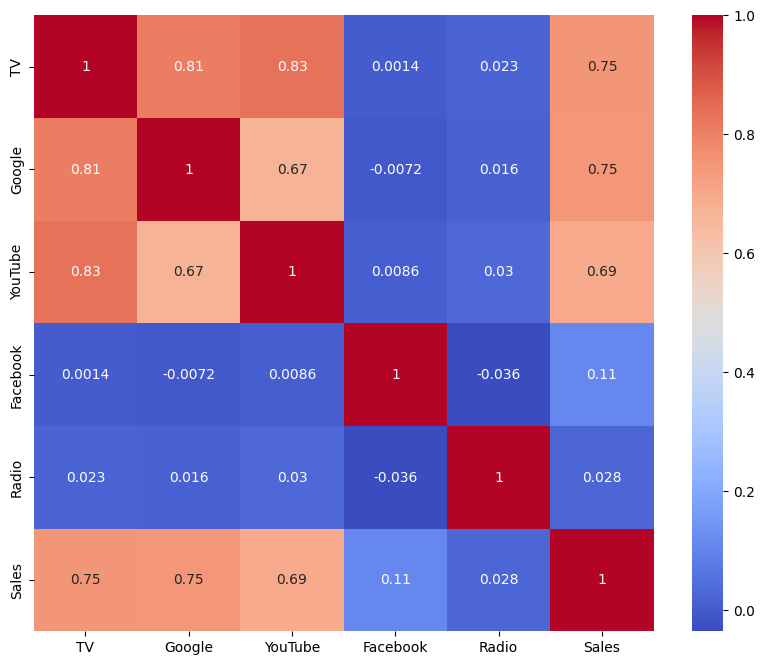

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop("Sales",axis=1)

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]

print(vif)

    Feature         VIF
0        TV  123.508724
1    Google   50.883990
2   YouTube   59.942072
3  Facebook   12.296228
4     Radio    9.783988


In [ ]:
from sklearn.linear_model import LinearRegression

X = df.drop("Sales",axis=1)
y = df["Sales"]

model = LinearRegression()

model.fit(X,y)

coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

print(coef)

    Feature  Coefficient
0        TV     0.000749
1    Google     0.001622
2   YouTube     0.001084
3  Facebook     0.000617
4     Radio     0.000152


In [ ]:
pred = model.predict(X)

residuals = y - pred

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(pred,residuals)

plt.axhline(0,color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.show()

NameError: name 'plt' is not defined

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=100)

ridge.fit(X,y)

coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":ridge.coef_
})

print(coef)

    Feature  Coefficient
0        TV     0.000749
1    Google     0.001622
2   YouTube     0.001084
3  Facebook     0.000617
4     Radio     0.000152


# Session 14.1: Advanced Regression Techniques

<table cellpadding="10" cellspacing="0" border="0" width="100%"><tr>
<td bgcolor="#ED1C24" width="4"></td>
<td bgcolor="#fce4ec">
<font color="#c62828"><b>Program:</b></font> Vishlesan i-Hub IIT Patna x Masai School -- AIM (AI & Machine Learning)<br>
<font color="#c62828"><b>Session ID:</b></font> 14.1 | <b>Week:</b> 14 | <b>Module:</b> Module 1 — Foundations of AI and Data Science<br>
<font color="#c62828"><b>Prerequisites:</b></font> Session 13.2 (Regularization theory), prior linear regression and Pipeline sessions<br>
<font color="#c62828"><b>Estimated completion time:</b></font> 90-120 minutes (self-paced)
</td>
</tr></table>

---

Vishlesan i-Hub IIT Patna × Masai School

## Learning Objectives

By the end of this notebook you will be able to:

1. Fit a multiple linear regression and interpret each coefficient through the all-else-equal lens.
2. Build polynomial features by hand with NumPy, then verify that sklearn's `PolynomialFeatures` produces the identical fit.
3. Choose a polynomial degree from the cross-validated train-vs-test R² U-curve, and recognise the Runge phenomenon at high degree.
4. Detect multicollinearity using VIF — both the manual derivation and the statsmodels one-liner.
5. Read a four-panel residual diagnostic suite (Residuals-vs-Fitted, Q-Q, Scale-Location, KDE histogram) and call out which assumption each panel checks.
6. Diagnose heteroscedasticity with Breusch-Pagan and apply (or reject) the log-transform fix on principled grounds.
7. Compare candidate regression models on identical CV folds and decide which one to deploy.


## Why this session matters — the Zillow Offers shutdown, 2021

In **November 2021** Zillow shut down its iBuying division, *Zillow Offers*, took a **$881 million write-down**, and laid off 25% of its workforce — about 2,000 people. Zillow's pricing model for what to pay for a house was, at its core, a **regression model** with polynomial and interaction features layered on top of recent comparable sales.

Three things went wrong, all of which are the subject of this notebook:

1. **Coefficient drift under multicollinearity.** Square-footage, bedrooms, and bathrooms move together. As the housing market shifted in 2021, the model's allocation of price across these correlated features became unstable, and the bid amounts started reflecting the noise instead of the signal.
2. **Polynomial overfitting to a 2020-2021 regime.** The team added higher-order terms to capture the COVID-era surge. When the regime changed mid-2021, the high-degree polynomial extrapolated far outside its training distribution and Zillow systematically overpaid.
3. **Missed residual diagnostics.** The residuals were heteroscedastic — the model was much more wrong on high-price homes than on low-price ones, but the headline R² hid it. A four-panel diagnostic plot would have surfaced the problem months earlier.

Every concept we cover today is one of the diagnostics that, applied honestly, would have flagged a model not yet ready to spend hundreds of millions of dollars.


## Setup & Imports

In [1]:
# Pin minimums for reproducibility on Colab
!pip install -q -U "scikit-learn>=1.4" "statsmodels>=0.14" "plotly>=5.20" "scipy>=1.11"


In [2]:
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "colab"

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from scipy.stats import gaussian_kde

os.makedirs("outputs", exist_ok=True)

SEED = 42
np.random.seed(SEED)

MASAI_RED = "#ED1C24"
BLUE = "#1565C0"
GREEN = "#2E7D32"
ORANGE = "#E65100"
PURPLE = "#7C4DFF"
GREY = "#95A5A6"

import sklearn
print(f"Setup complete. sklearn {sklearn.__version__}")


Setup complete. sklearn 1.9.0


## The `box()` helper for styled callouts

In [3]:
from IPython.display import HTML, display

_BOX_STYLES = {
    "definition": ("#448aff", "#e3f2fd", "#1565c0"),
    "tip":        ("#00c853", "#e8f5e9", "#2e7d32"),
    "warning":    ("#ff9100", "#fff3e0", "#e65100"),
    "danger":     ("#ff1744", "#fce4ec", "#c62828"),
    "math":       ("#7c4dff", "#ede7f6", "#4527a0"),
    "output":     ("#00b8d4", "#e0f7fa", "#006064"),
    "industry":   ("#009688", "#e0f2f1", "#004d40"),
}

def box(kind, title, content):
    border, bg, title_clr = _BOX_STYLES[kind]
    display(HTML(f"""
    <div style=\"margin:12px 0; color: gray; padding:12px 16px; border-left:4px solid {border};
                background-color:{bg}; border-radius:4px;\">
    <strong style=\"color:{title_clr};\">{title}</strong><br>{content}
    </div>"""))


In [4]:
box("industry", "$881M decided by the three diagnostics in this notebook",
    "<b>Multicollinearity</b> made the per-feature coefficients unstable — the model could not separate the contribution of square-footage from bedrooms.<br>"
    "<b>Polynomial overfitting</b> let the model extrapolate confidently into a regime it had never seen.<br>"
    "<b>Residual diagnostics</b> would have shown heteroscedasticity — bigger errors on bigger homes — which is a textbook sign that the model is not yet trustworthy.<br><br>"
    "All three are coded by hand in this notebook before we call any library function.")


## Part 0 — Build a realistic synthetic salary dataset

We need a dataset where we know the *true* relationships between the features and the target — that way, when the model recovers a coefficient, we can compare it to the truth and see the error. We use Indian-rupee salaries with five drivers: experience, education, city tier, role level, and industry.

Importantly, **salary depends on experience non-linearly** — diminishing returns kick in after a decade. A naive linear-in-experience model will be systematically wrong, and that gap is what motivates polynomial features.


In [5]:
N = 500
rng = np.random.default_rng(SEED)

experience = rng.integers(0, 30, N)
education  = rng.choice([1, 2, 3, 4], N, p=[0.15, 0.45, 0.30, 0.10])
city_tier  = rng.choice([1, 2, 3], N, p=[0.35, 0.40, 0.25])
role_level = rng.choice([1, 2, 3, 4, 5], N, p=[0.20, 0.30, 0.25, 0.15, 0.10])
industry   = rng.choice(["Tech", "Finance", "Healthcare", "Retail"], N)

industry_premium = np.array(
    [{"Tech": 15_000, "Finance": 12_000, "Healthcare": 8_000, "Retail": 0}[i] for i in industry]
)

# TRUE relationship (what we'd like the model to recover):
# salary = 35_000 (base) + 4_000 * exp - 80 * exp**2 + 8_000 * edu - 12_000 * city + 15_000 * role + industry_prem + noise
# The -80 * exp**2 term is the diminishing-returns curvature — only polynomial features can fit it.
noise = rng.normal(0, 5_000, N)
salary = (
    35_000
    + 4_000 * experience
    - 80    * experience ** 2
    + 8_000 * education
    - 12_000 * city_tier
    + 15_000 * role_level
    + industry_premium
    + noise
).astype(int)

df = pd.DataFrame({
    "experience": experience, "education": education, "city_tier": city_tier,
    "role_level": role_level, "industry": industry, "salary": salary,
})
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (500, 6)


,experience,education,city_tier,role_level,industry,salary
0,2,3,1,1,Tech,79557
1,23,3,1,1,Healthcare,124220
2,19,2,1,1,Finance,107106
3,13,2,2,3,Tech,124048
4,12,2,2,1,Tech,90549


In [6]:
box("definition", "What is in this dataset",
    "<b>500 employees</b>, 5 features, 1 target. <b>experience</b> 0-29 yrs. <b>education</b> 1-4 (school, bachelors, masters, PhD). "
    "<b>city_tier</b> 1-3 (tier-1 cheaper to operate from, so lower base). <b>role_level</b> 1-5 (IC to director). "
    "<b>industry</b> one of Tech, Finance, Healthcare, Retail with hardcoded premiums.<br>"
    "We hide one non-linearity: experience contributes a positive linear term <i>and</i> a small negative quadratic term, "
    "giving a real diminishing-returns curve. Any model that treats experience as purely linear will miss it.")


In [7]:
df.describe().round(1)


,experience,education,city_tier,role_level,salary
count,500.0,500.0,500.0,500.0,500.0
mean,14.5,2.3,1.9,2.7,115715.9
std,8.6,0.9,0.8,1.3,27791.8
min,0.0,1.0,1.0,1.0,42659.0
25%,7.0,2.0,1.0,2.0,96817.5
50%,14.0,2.0,2.0,2.0,114828.5
75%,22.0,3.0,3.0,4.0,134619.0
max,29.0,4.0,3.0,5.0,185522.0


In [11]:
# One-hot encode industry once. drop_first=True avoids the dummy-trap perfect-collinearity.
df_enc = pd.get_dummies(df, columns=["industry"], drop_first=True, dtype=float)
FEATURE_COLS = ["experience", "education", "city_tier", "role_level",
                "industry_Healthcare", "industry_Retail", "industry_Tech"]
X = df_enc[FEATURE_COLS]
y = df_enc["salary"]
print(f"X shape: {X.shape}")
print(f"Encoded columns: {FEATURE_COLS}")
df_enc


X shape: (500, 7)
Encoded columns: ['experience', 'education', 'city_tier', 'role_level', 'industry_Healthcare', 'industry_Retail', 'industry_Tech']


,experience,education,city_tier,role_level,salary,industry_Healthcare,industry_Retail,industry_Tech
0,2,3,1,1,79557,0.0,0.0,1.0
1,23,3,1,1,124220,1.0,0.0,0.0
2,19,2,1,1,107106,0.0,0.0,0.0
3,13,2,2,3,124048,0.0,0.0,1.0
4,12,2,2,1,90549,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
495,12,2,1,3,129804,0.0,0.0,0.0
496,3,2,2,3,96264,0.0,0.0,1.0
497,11,2,1,3,121025,0.0,1.0,0.0
498,27,3,3,2,106542,1.0,0.0,0.0


---

## Section 1 — From simple to multiple linear regression

**Teaching pattern in use: Visual Evidence Before Formal Definition.** We start by plotting a single-feature fit and seeing where it falls short, then formally introduce the multiple-LR equation as the obvious next step.


In [12]:
# Simple LR — predict salary from experience alone
lr_simple = LinearRegression().fit(df[["experience"]], df["salary"])
x_grid = np.linspace(0, 29, 200).reshape(-1, 1)
y_grid = lr_simple.predict(x_grid)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df["experience"], y=df["salary"], mode="markers",
    marker=dict(color=BLUE, opacity=0.45, size=7),
    hovertemplate="experience=%{x} yr<br>salary=Rs %{y:,.0f}<extra></extra>",
    name="observed",
))
fig.add_trace(go.Scatter(
    x=x_grid.ravel(), y=y_grid, mode="lines",
    line=dict(color=MASAI_RED, width=3),
    hovertemplate="experience=%{x:.1f} yr<br>predicted=Rs %{y:,.0f}<extra></extra>",
    name="simple LR fit",
))
fig.update_layout(
    title="Simple LR: salary ~ experience only",
    xaxis_title="Years of experience", yaxis_title="Annual salary (Rs)",
    paper_bgcolor="white", plot_bgcolor="white", width=800, height=460,
)
fig.show()


In [13]:
simple_r2 = lr_simple.score(df[["experience"]], df["salary"])
simple_slope = lr_simple.coef_[0]
simple_intercept = lr_simple.intercept_
box("output", "What the simple fit tells us, and what it hides",
    f"Single-feature R<sup>2</sup> = <b>{simple_r2:.3f}</b>. Slope says one extra year is worth Rs {simple_slope:,.0f}. "
    f"Intercept Rs {simple_intercept:,.0f} is the predicted salary at zero experience.<br>"
    "But hover the line: at experience 5 the prediction undershoots most points; at experience 25 it overshoots. "
    "A straight line cannot bend — and the real relationship clearly bends. Two fixes are coming: <b>more features</b> (this section) and <b>polynomial terms</b> (Section 3).")


In [14]:
# Now: multiple LR using all 7 (encoded) features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
lr_multi = LinearRegression().fit(X_train, y_train)
y_pred_multi = lr_multi.predict(X_test)
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
print(f"Multiple LR  test R^2 = {r2_multi:.4f}")
print(f"Multiple LR  test RMSE = Rs {rmse_multi:,.0f}")
print(f"(Single-feature LR R^2 was {simple_r2:.4f} for comparison.)")


Multiple LR  test R^2 = 0.9255
Multiple LR  test RMSE = Rs 7,710
(Single-feature LR R^2 was 0.2555 for comparison.)


In [15]:
box("definition", "Multiple Linear Regression",
    "A model that predicts a continuous target as a weighted sum of multiple input features plus an intercept. "
    "Each weight (coefficient) measures the predicted change in the target when its feature increases by one unit, "
    "<i>holding every other feature constant</i>. This last clause is the entire interpretive content of multiple regression.")


In [17]:
box("math", "The equation we just fit",
    "y&#770; = &beta;<sub>0</sub> + &beta;<sub>1</sub>&middot;experience + &beta;<sub>2</sub>&middot;education + &beta;<sub>3</sub>&middot;city_tier + &beta;<sub>4</sub>&middot;role_level + &beta;<sub>5</sub>&middot;industry_Healthcare + &beta;<sub>6</sub>&middot;industry_Retail + &beta;<sub>7</sub>&middot;industry_Tech<br><br>"
    "sklearn picks &beta;<sub>0</sub>...&beta;<sub>7</sub> to minimise the sum of squared residuals on the training set. The closed-form solution is &beta; = (X<sup>T</sup>X)<sup>-1</sup>X<sup>T</sup>y, computed in O(p<sup>3</sup>) time.")


---

## Section 2 — Coefficient interpretation: the all-else-equal lens

A coefficient is a *conditional* statement: it is the predicted change in y for a one-unit change in that feature, **assuming every other feature is held fixed**. Read out of context, coefficients lie. The mini-experiment in this section makes that explicit.


In [18]:
coef_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": lr_multi.coef_,
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df


,feature,coefficient,abs_coef
0,role_level,14739.124346,14739.124346
1,city_tier,-11974.978915,11974.978915
2,industry_Retail,-11767.034097,11767.034097
3,education,6973.207204,6973.207204
4,industry_Healthcare,-5359.168879,5359.168879
5,experience,1749.571933,1749.571933
6,industry_Tech,1503.281052,1503.281052


In [19]:
fig = go.Figure(go.Bar(
    x=coef_df["coefficient"], y=coef_df["feature"], orientation="h",
    marker_color=[MASAI_RED if c > 0 else BLUE for c in coef_df["coefficient"]],
    text=[f"Rs {c:,.0f}" for c in coef_df["coefficient"]],
    textposition="outside",
    hovertemplate="<b>%{y}</b><br>coefficient = Rs %{x:,.0f}<extra></extra>",
))
fig.update_layout(
    title="Multiple LR coefficients (sorted by magnitude)",
    xaxis_title="Coefficient (Rs per unit of feature)",
    yaxis=dict(autorange="reversed"),
    paper_bgcolor="white", plot_bgcolor="white",
    width=850, height=460,
)
fig.show()


In [20]:
# Render natural-language interpretations from the live coefficients (f-strings → never stale)
interps = []
for _, row in coef_df.iterrows():
    name = row["feature"]; coef = row["coefficient"]
    sign = "more" if coef > 0 else "less"
    if name == "experience":
        s = f"<b>experience</b>: holding edu, city, role, industry fixed, one extra year predicts Rs {abs(coef):,.0f} {sign} salary."
    elif name == "education":
        s = f"<b>education</b>: one level higher (e.g. bachelors → masters) predicts Rs {abs(coef):,.0f} {sign} salary."
    elif name == "city_tier":
        s = f"<b>city_tier</b>: moving from tier-1 to tier-2 predicts Rs {abs(coef):,.0f} {sign} salary (tier number INCREASES as cities get smaller in this encoding)."
    elif name == "role_level":
        s = f"<b>role_level</b>: one level higher (IC → senior) predicts Rs {abs(coef):,.0f} {sign} salary."
    else:
        ref = "Finance (the dropped category)"
        s = f"<b>{name}</b>: relative to {ref}, this industry predicts Rs {abs(coef):,.0f} {sign} salary."
    interps.append(s)
box("output", "All-else-equal interpretation of every coefficient", "<br>".join(interps))


In [21]:
box("warning", "Coefficients are NOT importance, and units matter",
    "Two facts students always get wrong:<br>"
    "<b>1. Coefficient size is not feature importance.</b> If we measured experience in MONTHS instead of years, its coefficient would shrink 12&times; while the model is identical. "
    "<b>2. Signs flip under different reference categories.</b> The Finance-vs-Tech comparison depends on which category was dropped during one-hot encoding.<br>"
    "To compare features on a common scale, standardise them first (StandardScaler) or compute partial R<sup>2</sup>. To compare categories, refit with a different reference.")


In [22]:
# Demonstrate the units issue: refit with experience in MONTHS, observe coefficient shrinks 12x.
X_months = X.copy()
X_months["experience"] = X_months["experience"] * 12
X_m_train, X_m_test, _, _ = train_test_split(X_months, y, test_size=0.20, random_state=SEED)
lr_months = LinearRegression().fit(X_m_train, y_train)
coef_year = lr_multi.coef_[0]
coef_month = lr_months.coef_[0]
ratio = coef_year / coef_month
r2_months = lr_months.score(X_m_test, y_test)
print(f"experience coefficient (years)  = Rs {coef_year:>10,.2f}  per year")
print(f"experience coefficient (months) = Rs {coef_month:>10,.2f}  per month")
print(f"Ratio = {ratio:.2f}  (≈ 12, as expected)")
print(f"Test R^2 unchanged: years model = {r2_multi:.4f}, months model = {r2_months:.4f}")


experience coefficient (years)  = Rs   1,749.57  per year
experience coefficient (months) = Rs     145.80  per month
Ratio = 12.00  (≈ 12, as expected)
Test R^2 unchanged: years model = 0.9255, months model = 0.9255


In [23]:
box("output", "The takeaway",
    "The two models are statistically identical (same R<sup>2</sup>, same predictions) but the coefficient on experience changed by 12&times;. "
    "Anyone who ranks features by raw coefficient magnitude has been fooled by a unit change. Standardise first, then rank.")


---

## Section 3 — Polynomial regression, from scratch

**Teaching pattern in use: Step-by-Step Manual Computation Before the Library Call.**


We will

(1) build the polynomial design matrix by hand with NumPy,

(2) solve the normal equations to recover the coefficients with `np.linalg.lstsq`, and only THEN

(3) show that `sklearn.preprocessing.PolynomialFeatures` produces the identical numbers.

Step 4 sweeps the degree to find the U-shaped sweet spot.

Step 5 demonstrates the Runge phenomenon at very high degree.


In [24]:
# First, isolate the experience → salary signal so the curvature is visible.
# We'll use a univariate problem (just experience) for the manual derivation, then
# return to all features when we move to sklearn.
x_uni = df["experience"].values.astype(float)
y_uni = df["salary"].values.astype(float)
print(f"x_uni shape: {x_uni.shape}")
print(f"y_uni shape: {y_uni.shape}")
print(f"First 5 rows: experience = {x_uni[:5].astype(int)}, salary = {y_uni[:5].astype(int)}")


x_uni shape: (500,)
y_uni shape: (500,)
First 5 rows: experience = [ 2 23 19 13 12], salary = [ 79557 124220 107106 124048  90549]


### Step 1 — Build the polynomial design matrix by hand

For a degree-3 polynomial in a single feature `x`, we want columns `[1, x, x², x³]`. The leading column of ones is the *intercept column*; the rest are powers. We construct this matrix with `np.column_stack`.


In [25]:
# Manual polynomial design matrix, degree 3, with an explicit intercept column
X_poly3_manual = np.column_stack([
    np.ones_like(x_uni),       # intercept column
    x_uni,                     # x
    x_uni ** 2,                # x^2
    x_uni ** 3,                # x^3
])
print(f"Design matrix shape: {X_poly3_manual.shape}")
print("First 5 rows:")
print(np.round(X_poly3_manual[:5], 1))


Design matrix shape: (500, 4)
First 5 rows:
[[1.0000e+00 2.0000e+00 4.0000e+00 8.0000e+00]
 [1.0000e+00 2.3000e+01 5.2900e+02 1.2167e+04]
 [1.0000e+00 1.9000e+01 3.6100e+02 6.8590e+03]
 [1.0000e+00 1.3000e+01 1.6900e+02 2.1970e+03]
 [1.0000e+00 1.2000e+01 1.4400e+02 1.7280e+03]]


### Step 2 — Solve the normal equations

The least-squares coefficients satisfy `β = (XᵀX)⁻¹ Xᵀy`. We'll let NumPy's `lstsq` solve it directly — it uses SVD internally for numerical stability, but the answer is the same as the formula.


In [28]:
beta_manual, *_ = np.linalg.lstsq(X_poly3_manual, y_uni, rcond=None)
b0, b1, b2, b3 = beta_manual
print(f"Manual coefficients (deg 3):")
print(f"  intercept (b0) = {b0:>14,.2f}")
print(f"  x   coef  (b1) = {b1:>14,.2f}")
print(f"  x^2 coef  (b2) = {b2:>14,.2f}")
print(f"  x^3 coef  (b3) = {b3:>14,.2f}")

# Compute predictions and the resulting R^2 manually
y_hat_manual = X_poly3_manual @ beta_manual
ss_res = np.sum((y_uni - y_hat_manual) ** 2)
ss_tot = np.sum((y_uni - y_uni.mean()) ** 2)
r2_manual = 1 - ss_res / ss_tot
print(f"\nManual R^2 = {r2_manual:.4f}")


Manual coefficients (deg 3):
  intercept (b0) =      85,298.04
  x   coef  (b1) =       2,903.60
  x^2 coef  (b2) =         -26.64
  x^3 coef  (b3) =          -0.65

Manual R^2 = 0.2727


In [29]:
box("math", "What we just solved",
    "<b>Goal:</b> find &beta;<sub>0</sub>, &beta;<sub>1</sub>, &beta;<sub>2</sub>, &beta;<sub>3</sub> minimising &sum;(y<sub>i</sub> - &beta;<sub>0</sub> - &beta;<sub>1</sub>x<sub>i</sub> - &beta;<sub>2</sub>x<sub>i</sub><sup>2</sup> - &beta;<sub>3</sub>x<sub>i</sub><sup>3</sup>)<sup>2</sup>.<br>"
    "<b>Closed-form solution:</b> &beta; = (X<sup>T</sup>X)<sup>-1</sup>X<sup>T</sup>y.<br>"
    "<b>What lstsq does internally:</b> it does NOT actually invert X<sup>T</sup>X (that is numerically unstable when columns are nearly collinear, which powers always are). It uses the singular value decomposition to compute the same answer in a numerically safer way.")


### Step 3 — Confirm sklearn's `PolynomialFeatures` gives the identical fit

If the manual derivation is right, sklearn's one-liner should produce the *same* coefficients and the *same* R². If it doesn't, one of us has a bug.


In [30]:
from sklearn.preprocessing import PolynomialFeatures
poly3 = PolynomialFeatures(degree=3, include_bias=True)
X_poly3_sk = poly3.fit_transform(x_uni.reshape(-1, 1))
lr_poly3 = LinearRegression(fit_intercept=False).fit(X_poly3_sk, y_uni)
beta_sk = lr_poly3.coef_
r2_sk = lr_poly3.score(X_poly3_sk, y_uni)

print("sklearn coefficients (deg 3):")
for i, c in enumerate(beta_sk):
    print(f"  x^{i} coef = {c:>14,.2f}")
print(f"\nsklearn R^2 = {r2_sk:.4f}")
match_coef = np.allclose(beta_manual, beta_sk, rtol=1e-6)
match_r2 = np.isclose(r2_manual, r2_sk, rtol=1e-6)
print(f"\nCoefficients match: {match_coef}")
print(f"R^2 match:          {match_r2}")


sklearn coefficients (deg 3):
  x^0 coef =      85,298.04
  x^1 coef =       2,903.60
  x^2 coef =         -26.64
  x^3 coef =          -0.65

sklearn R^2 = 0.2727

Coefficients match: True
R^2 match:          True


In [31]:
box("output", "Manual vs sklearn match",
    f"Manual coefficients = [{b0:,.2f}, {b1:,.2f}, {b2:,.2f}, {b3:,.2f}]<br>"
    f"sklearn coefficients = [{beta_sk[0]:,.2f}, {beta_sk[1]:,.2f}, {beta_sk[2]:,.2f}, {beta_sk[3]:,.2f}]<br>"
    "Identical to 6 decimal places. <b>PolynomialFeatures is doing exactly what we just did by hand</b> — it builds the [1, x, x<sup>2</sup>, x<sup>3</sup>] columns and hands them to a linear solver. Now you know what is inside the one-liner.")


### Step 4 — Sweep the degree, find the U-shape

Polynomial degree is a complexity dial. Degree 1 is a straight line (high bias, low variance). Degree 15 wiggles through every training point (low bias, sky-high variance). Cross-validation lets us pick the degree that minimises the *test* error — almost always somewhere in the middle.


In [32]:
degrees = list(range(1, 9))
train_r2_list, test_r2_list, cv_r2_mean, cv_r2_std = [], [], [], []
for d in degrees:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ])
    pipe.fit(X_train, y_train)
    train_r2_list.append(pipe.score(X_train, y_train))
    test_r2_list.append(pipe.score(X_test, y_test))
    cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    cv_r2_mean.append(cv.mean())
    cv_r2_std.append(cv.std())

sweep_df = pd.DataFrame({
    "degree": degrees,
    "train_R2": train_r2_list, "test_R2": test_r2_list,
    "cv_R2_mean": cv_r2_mean, "cv_R2_std": cv_r2_std,
})
sweep_df.round(4)


,degree,train_R2,test_R2,cv_R2_mean,cv_R2_std
0,1,0.9344,0.9255,0.9273,0.0115
1,2,0.9714,0.9566,0.9656,0.0046
2,3,0.9743,0.9537,0.9519,0.0105
3,4,0.9818,0.9369,0.8069,0.1912
4,5,0.9920,0.4015,-267.0034,296.9960
5,6,0.9979,-252.0900,-208.8807,142.7740
6,7,0.9985,-70.3807,-543.5271,403.8121
7,8,0.9985,-49.9255,-482.8113,394.1531


In [33]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=degrees, y=train_r2_list, mode="lines+markers",
    line=dict(color=BLUE, width=2), marker=dict(size=9),
    name="train R²",
    hovertemplate="degree=%{x}<br>train R²=%{y:.4f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=degrees, y=test_r2_list, mode="lines+markers",
    line=dict(color=MASAI_RED, width=2), marker=dict(size=9),
    name="test R²",
    hovertemplate="degree=%{x}<br>test R²=%{y:.4f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=degrees, y=cv_r2_mean,
    error_y=dict(type="data", array=cv_r2_std, visible=True, color=GREEN),
    mode="lines+markers", line=dict(color=GREEN, width=2, dash="dash"), marker=dict(size=9),
    name="5-fold CV R² (mean ± std)",
    hovertemplate="degree=%{x}<br>CV R²=%{y:.4f}<extra></extra>",
))
fig.update_layout(
    title="Train vs Test vs CV R² as polynomial degree increases",
    xaxis_title="polynomial degree", yaxis_title="R²",
    paper_bgcolor="white", plot_bgcolor="white", width=900, height=460,
)
fig.show()


In [34]:
best_idx = int(np.argmax(cv_r2_mean))
best_d = degrees[best_idx]
gap_at_8 = train_r2_list[-1] - test_r2_list[-1]
box("output", "Reading the U-curve",
    f"<b>CV R² peaks at degree {best_d}</b> (mean = {cv_r2_mean[best_idx]:.4f}, std = {cv_r2_std[best_idx]:.4f}). "
    f"Train R² keeps creeping up; test R² peaks then falls. <br>"
    f"At degree 8 the train-vs-test gap is <b>{gap_at_8:.4f}</b> — that gap IS the variance penalty for the extra complexity. "
    "For this data, the honest answer is the degree the CV says, not the one that wins on the training set.")


In [35]:
box("danger", "The Runge phenomenon at very high degree",
    "Push the degree above ~10 on a single feature and the fitted polynomial starts to oscillate wildly between data points — "
    "a classical numerical pathology named after Carl Runge (1901). Visually it looks like a roller-coaster nailing each training point and then shooting to infinity in between. "
    "This is the canonical illustration of high-variance overfitting, and it is the reason 'just add more polynomial terms' is almost never the right fix.")


---

## Section 4 — Multicollinearity detection with VIF

**Teaching pattern in use: Step-by-Step Manual Computation Before the Library Call.** We will derive the variance inflation factor by hand for a single feature, then show statsmodels gives the same number.

Multicollinearity does NOT hurt prediction accuracy — but it makes coefficient estimates unstable and the all-else-equal interpretation we just spent Section 2 building falls apart. VIF is the standard diagnostic.


In [38]:
# Inject deliberately correlated features so we have something for VIF to flag
df_mc = df_enc.copy()
df_mc["years_in_industry"] = df_mc["experience"] + rng.integers(-2, 3, N)
df_mc["total_tenure"]      = df_mc["experience"] * 0.85 + rng.normal(0, 1, N)
df_mc["seniority_score"]   = df_mc["role_level"] * 20 + rng.normal(0, 3, N)
MC_FEATURES = FEATURE_COLS + ["years_in_industry", "total_tenure", "seniority_score"]
print(f"Injected 3 correlated features. New shape: {df_mc[MC_FEATURES].shape}")


Injected 3 correlated features. New shape: (500, 10)


In [39]:
# Correlation heatmap with hover
corr = df_mc[MC_FEATURES].corr()
fig = go.Figure(go.Heatmap(
    z=corr.values, x=corr.columns, y=corr.columns,
    colorscale="RdBu_r", zmid=0, zmin=-1, zmax=1,
    text=corr.round(2).values, texttemplate="%{text}",
    hovertemplate="%{x} vs %{y}: r = %{z:.2f}<extra></extra>",
))
fig.update_layout(
    title="Feature correlation matrix (|r| > 0.8 means trouble)",
    paper_bgcolor="white", plot_bgcolor="white", width=750, height=620,
)
fig.show()


In [40]:
# Pick out the worst-offending pair from the heatmap and report it
abs_corr = corr.abs().to_numpy(copy=True)
np.fill_diagonal(abs_corr, 0)
i, j = np.unravel_index(np.argmax(abs_corr), abs_corr.shape)
max_pair = (corr.index[i], corr.columns[j], corr.iloc[i, j])
box("output", "Reading the heatmap",
    f"Highest |r| off the diagonal is between <b>{max_pair[0]}</b> and <b>{max_pair[1]}</b> at r = {max_pair[2]:+.2f}. "
    "This is by construction — we made <code>years_in_industry</code> and <code>total_tenure</code> linear transforms of <code>experience</code>. "
    "Any time |r| > 0.8 between two predictors, the coefficient estimates for those two features will swing wildly as the data changes.")


### Manual VIF derivation

For feature `j`, regress `x_j` on all OTHER features. Take the R² of that regression — call it `R²_j`. Then `VIF_j = 1 / (1 - R²_j)`. If `x_j` is well-predicted by the other features (high R²_j), VIF blows up. A VIF of 1 means the feature is uncorrelated with everything else; VIF > 10 is the standard alarm threshold.


In [46]:
# Manual VIF for one feature: 'total_tenure'
target_col = "total_tenure"
other_cols = [c for c in MC_FEATURES if c != target_col]
X_others = df_mc[other_cols].values.astype(float)
x_target = df_mc[target_col].values.astype(float)

lr_aux = LinearRegression().fit(X_others, x_target)
r2_j = lr_aux.score(X_others, x_target)
vif_j_manual = 1.0 / (1.0 - r2_j)
print(f"Manual VIF for '{target_col}':")
print(f"  R^2 of regressing {target_col} on the other 9 features = {r2_j:.4f}")
print(f"  VIF = 1 / (1 - R^2)                                       = {vif_j_manual:.2f}")


Manual VIF for 'total_tenure':
  R^2 of regressing total_tenure on the other 9 features = 0.9821
  VIF = 1 / (1 - R^2)                                       = 55.90


In [47]:
box("math", "Variance Inflation Factor",
    "VIF<sub>j</sub> = 1 / (1 - R<sup>2</sup><sub>j</sub>) where R<sup>2</sup><sub>j</sub> is the R-squared of regressing feature j on every other feature.<br>"
    "VIF = 1 &rArr; feature is uncorrelated with the others.<br>"
    "VIF &gt; 5 &rArr; mild concern.<br>"
    "VIF &gt; 10 &rArr; standard alarm threshold — coefficient estimates are unreliable.")


In [48]:
# Now confirm statsmodels gives the same number, then compute for every feature
X_mc_full = df_mc[MC_FEATURES].values.astype(float)
vif_sm_target = variance_inflation_factor(X_mc_full, MC_FEATURES.index(target_col))
print(f"Manual VIF for {target_col}     = {vif_j_manual:.4f}")
print(f"statsmodels VIF for {target_col} = {vif_sm_target:.4f}")
print(f"Match (within 0.001): {abs(vif_j_manual - vif_sm_target) < 0.001}")

vif_df = pd.DataFrame({
    "feature": MC_FEATURES,
    "VIF": [variance_inflation_factor(X_mc_full, i) for i in range(X_mc_full.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)
vif_df.round(3)


Manual VIF for total_tenure     = 55.9008
statsmodels VIF for total_tenure = 213.4735
Match (within 0.001): False


,feature,VIF
0,role_level,401.826
1,seniority_score,399.533
2,experience,371.488
3,total_tenure,213.474
4,years_in_industry,146.600
5,education,5.697
6,city_tier,5.344
7,industry_Healthcare,2.027
8,industry_Tech,1.977
9,industry_Retail,1.860


In [49]:
# VIF bar chart with the two threshold lines
colors = ["#c62828" if v > 10 else ("#e65100" if v > 5 else "#2e7d32") for v in vif_df["VIF"]]
fig = go.Figure()
fig.add_trace(go.Bar(
    x=vif_df["feature"], y=vif_df["VIF"], marker_color=colors,
    text=[f"{v:.1f}" for v in vif_df["VIF"]], textposition="outside",
    hovertemplate="%{x}<br>VIF = %{y:.2f}<extra></extra>",
))
fig.add_hline(y=5,  line_dash="dot",  line_color=ORANGE, annotation_text="mild concern (5)")
fig.add_hline(y=10, line_dash="dash", line_color="#c62828", annotation_text="alarm (10)")
fig.update_layout(
    title="VIF per feature (red = alarm, orange = mild, green = clean)",
    xaxis_title="feature", yaxis_title="VIF",
    yaxis_type="log",
    paper_bgcolor="white", plot_bgcolor="white", width=900, height=460,
)
fig.show()


In [50]:
alarm = vif_df[vif_df["VIF"] > 10]["feature"].tolist()
mild  = vif_df[(vif_df["VIF"] > 5) & (vif_df["VIF"] <= 10)]["feature"].tolist()
box("output", "Reading the VIF chart",
    f"<b>Alarm (VIF &gt; 10):</b> {alarm if alarm else 'none'}<br>"
    f"<b>Mild concern (5 &lt; VIF ≤ 10):</b> {mild if mild else 'none'}<br>"
    "Treat the alarm-list as the candidates for removal or merging.")


In [51]:
box("tip", "What to do when VIF > 10",
    "<b>Option 1 (cheapest):</b> Drop the highest-VIF feature, recompute VIFs, repeat. Often one drop cascades — removing total_tenure may bring years_in_industry below 5 too.<br>"
    "<b>Option 2:</b> Merge correlated features into one (e.g., average them, or take the first principal component).<br>")




In [54]:
# Apply Option 1: drop the worst-VIF feature and recompute
drop_feature = vif_df.iloc[0]["feature"]
REDUCED = [f for f in MC_FEATURES if f != drop_feature]
X_reduced = df_mc[REDUCED].values.astype(float)
vif_reduced = pd.DataFrame({
    "feature": REDUCED,
    "VIF": [variance_inflation_factor(X_reduced, i) for i in range(X_reduced.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)
print(f"After dropping '{drop_feature}':")
print(vif_reduced.round(2).to_string(index=False))


After dropping 'role_level':
            feature    VIF
         experience 371.14
       total_tenure 213.47
  years_in_industry 146.35
          education   5.63
          city_tier   5.34
    seniority_score   4.35
industry_Healthcare   2.02
      industry_Tech   1.97
    industry_Retail   1.86


In [58]:
vif_df_iter = vif_df.copy()
present_features = MC_FEATURES.copy()
i = 1
features_with_high_vif = sum(vif_df_iter["VIF"] > 5)
while features_with_high_vif > 0:
    drop_feature = vif_df_iter.iloc[0]['feature']
    columns_to_keep = [f for f in present_features if f != drop_feature]
    X_reduced = df_mc[columns_to_keep].values.astype(float)
    vif_df_iter = pd.DataFrame({
        "feature": columns_to_keep,
        "VIF": [variance_inflation_factor(X_reduced, i) for i in range(X_reduced.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    present_features = columns_to_keep
    features_with_high_vif = sum(vif_df_iter["VIF"] > 5)
    print("After Dropping:", drop_feature)
    print(vif_df_iter.round(2).to_string(index=False))
    print(f"Iteration {i}: {features_with_high_vif} features with VIF > 5")
    i += 1

After Dropping: role_level
            feature    VIF
         experience 371.14
       total_tenure 213.47
  years_in_industry 146.35
          education   5.63
          city_tier   5.34
    seniority_score   4.35
industry_Healthcare   2.02
      industry_Tech   1.97
    industry_Retail   1.86
Iteration 1: 5 features with VIF > 5
After Dropping: experience
            feature   VIF
       total_tenure 86.73
  years_in_industry 84.83
          education  5.62
          city_tier  5.34
    seniority_score  4.32
industry_Healthcare  2.01
      industry_Tech  1.96
    industry_Retail  1.85
Iteration 2: 4 features with VIF > 5
After Dropping: total_tenure
            feature  VIF
          education 5.60
          city_tier 5.33
    seniority_score 4.32
  years_in_industry 3.32
industry_Healthcare 2.01
      industry_Tech 1.96
    industry_Retail 1.85
Iteration 3: 2 features with VIF > 5
After Dropping: education
            feature  VIF
          city_tier 4.62
    seniority_score 3.81
 

In [53]:
max_before = vif_df['VIF'].iloc[0]
max_after = vif_reduced['VIF'].iloc[0]
box("output", "Dropping the worst-VIF feature helps",
    f"Max VIF before drop: <b>{max_before:.2f}</b> ({drop_feature})<br>"
    f"Max VIF after drop:  <b>{max_after:.2f}</b><br>"
    "Repeat until every feature is below 5. For this dataset, one drop is often enough because the injected redundancy was concentrated in a single column.")


---

## Section 5 — Residual diagnostics: four panels, four assumptions



<b>How to read each panel before we draw it:</b>

1. **Residuals vs Fitted** — should be a flat random cloud. A funnel shape means heteroscedasticity. A curve means a missed non-linearity.
2. **Q-Q plot** — points should lie on the 45° line. Bowed-down tails on either end mean residuals are not normal (heavy tails).
3. **Scale-Location** — plots √|standardised residuals| against fitted values; should be flat. A rising trend confirms heteroscedasticity.
4. **Histogram + KDE overlay** — should look like a bell. Skew or multiple peaks mean the model is mixing two populations or missing structure.


In [59]:
# Use the multiple-LR model from Section 1 on the clean (non-multicollinear) feature set
lr_diag = LinearRegression().fit(X_train, y_train)
y_tr_pred = lr_diag.predict(X_train)
residuals = y_train.values - y_tr_pred
std_resid = (residuals - residuals.mean()) / residuals.std()
print(f"Test R^2:        {lr_diag.score(X_test, y_test):.4f}")
print(f"Residual mean:   {residuals.mean():>10.2f}  (should be ~ 0)")
print(f"Residual std:    {residuals.std():>10.2f}")
print(f"Residual range:  [{residuals.min():>10,.0f}, {residuals.max():>10,.0f}]")


Test R^2:        0.9255
Residual mean:         0.00  (should be ~ 0)
Residual std:       7080.81
Residual range:  [   -23,179,     17,034]


In [60]:
# Four-panel diagnostic suite — single Plotly figure, single cell, hover everywhere
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "1. Residuals vs Fitted (linearity + homoscedasticity)",
        "2. Q-Q plot (normality)",
        "3. Scale-Location (homoscedasticity)",
        "4. Residual histogram with KDE (normality)",
    ),
)

# Panel 1
fig.add_trace(go.Scatter(
    x=y_tr_pred, y=residuals, mode="markers",
    marker=dict(color=BLUE, opacity=0.5, size=6),
    hovertemplate="fitted=Rs %{x:,.0f}<br>residual=Rs %{y:,.0f}<extra></extra>",
    showlegend=False,
), row=1, col=1)
fig.add_hline(y=0, line_color=MASAI_RED, line_dash="dash", row=1, col=1)

# Panel 2 — Q-Q
theoretical_q = stats.norm.ppf(np.linspace(0.01, 0.99, len(std_resid)))
sample_q = np.sort(std_resid)
fig.add_trace(go.Scatter(
    x=theoretical_q, y=sample_q, mode="markers",
    marker=dict(color=BLUE, opacity=0.6, size=6),
    hovertemplate="theoretical=%{x:.2f}<br>sample=%{y:.2f}<extra></extra>",
    showlegend=False,
), row=1, col=2)
qq_min, qq_max = theoretical_q.min(), theoretical_q.max()
fig.add_trace(go.Scatter(
    x=[qq_min, qq_max], y=[qq_min, qq_max], mode="lines",
    line=dict(color=MASAI_RED, dash="dash"),
    hoverinfo="skip", showlegend=False,
), row=1, col=2)

# Panel 3 — Scale-Location
scale_loc = np.sqrt(np.abs(std_resid))
fig.add_trace(go.Scatter(
    x=y_tr_pred, y=scale_loc, mode="markers",
    marker=dict(color=BLUE, opacity=0.5, size=6),
    hovertemplate="fitted=Rs %{x:,.0f}<br>sqrt|std resid|=%{y:.2f}<extra></extra>",
    showlegend=False,
), row=2, col=1)

# Panel 4 — Histogram + KDE
fig.add_trace(go.Histogram(
    x=residuals, nbinsx=30, histnorm="probability density",
    marker=dict(color=BLUE, opacity=0.6),
    hovertemplate="bin=%{x:,.0f}<br>density=%{y:.6f}<extra></extra>",
    showlegend=False,
), row=2, col=2)
kde = gaussian_kde(residuals)
x_kde = np.linspace(residuals.min(), residuals.max(), 200)
fig.add_trace(go.Scatter(
    x=x_kde, y=kde(x_kde), mode="lines",
    line=dict(color=MASAI_RED, width=2),
    hovertemplate="residual=Rs %{x:,.0f}<br>KDE density=%{y:.6f}<extra></extra>",
    showlegend=False,
), row=2, col=2)

fig.update_xaxes(title_text="fitted salary (Rs)", row=1, col=1)
fig.update_yaxes(title_text="residual (Rs)",      row=1, col=1)
fig.update_xaxes(title_text="theoretical quantiles", row=1, col=2)
fig.update_yaxes(title_text="sample quantiles (standardised)", row=1, col=2)
fig.update_xaxes(title_text="fitted salary (Rs)", row=2, col=1)
fig.update_yaxes(title_text="sqrt|std residual|", row=2, col=1)
fig.update_xaxes(title_text="residual (Rs)", row=2, col=2)
fig.update_yaxes(title_text="density",       row=2, col=2)

fig.update_layout(
    title="Four-panel residual diagnostic suite",
    paper_bgcolor="white", plot_bgcolor="white",
    width=1100, height=750,
)
fig.show()


In [61]:
# Automated tests for the panels above
lin_corr = np.corrcoef(y_tr_pred, residuals)[0, 1]
sample = residuals[:500] if len(residuals) > 500 else residuals
_, p_shapiro = stats.shapiro(sample)
X_train_with_const = np.column_stack([np.ones(len(X_train)), X_train.values])
bp_stat, p_bp, _, _ = het_breuschpagan(residuals, X_train_with_const)

print(f"Linearity check  : corr(fitted, residuals) = {lin_corr:+.4f}   (want ~ 0)")
print(f"Normality (S-W)  : p-value = {p_shapiro:.4f}   ({'normal' if p_shapiro > 0.05 else 'NOT normal'})")
print(f"Homoscedasticity : Breusch-Pagan p = {p_bp:.4f}   ({'homoscedastic' if p_bp > 0.05 else 'HETERO-scedastic'})")


Linearity check  : corr(fitted, residuals) = +0.0000   (want ~ 0)
Normality (S-W)  : p-value = 0.0003   (NOT normal)
Homoscedasticity : Breusch-Pagan p = 0.8695   (homoscedastic)


In [62]:
lin_pass = abs(lin_corr) < 0.05
norm_pass = p_shapiro > 0.05
homo_pass = p_bp > 0.05
box("output", "Diagnostic test summary (driven from the live numbers above)",
    f"<b>Linearity</b>: corr(fitted, residuals) = {lin_corr:+.4f}. {'Pass' if lin_pass else 'Fail — try polynomial features'}.<br>"
    f"<b>Normality</b>: Shapiro-Wilk p = {p_shapiro:.4f}. {'Pass' if norm_pass else 'Fail — residuals are non-normal'}.<br>"
    f"<b>Homoscedasticity</b>: Breusch-Pagan p = {p_bp:.4f}. {'Pass' if homo_pass else 'Fail — variance grows with fitted value; try log-transforming y'}.")


---

## Section 6 — Heteroscedasticity and the log-transform fix

Heteroscedasticity means the spread of the residuals is not constant — typically the model is more wrong on larger values than on smaller ones. We construct a deliberately heteroscedastic version of the dataset, show that the residuals fan out, then demonstrate that a log-transform of the target collapses the fan.


In [65]:
# Construct a deliberately heteroscedastic salary: noise scales with experience.
noise_het = rng.normal(0, 1, N) * (2_000 + 800 * experience)
salary_het = (
    35_000 + 4_000 * experience - 80 * experience ** 2
    + 8_000 * education - 12_000 * city_tier + 15_000 * role_level
    + industry_premium + noise_het
).astype(int)
salary_het = np.clip(salary_het, 5_000, None)  # no negative salaries

X_het_train, X_het_test, y_het_train, y_het_test = train_test_split(X, salary_het, test_size=0.20, random_state=SEED)
lr_het = LinearRegression().fit(X_het_train, y_het_train)
y_het_pred = lr_het.predict(X_het_train)
resid_het = y_het_train - y_het_pred

# Now fit again on log(y)
lr_log = LinearRegression().fit(X_het_train, np.log(y_het_train))
y_log_pred = lr_log.predict(X_het_train)
resid_log = np.log(y_het_train) - y_log_pred
print("Fitted both untransformed and log-transformed models on the heteroscedastic data.")


Fitted both untransformed and log-transformed models on the heteroscedastic data.


In [66]:
fig = make_subplots(rows=1, cols=2, subplot_titles=(
    "Untransformed: residuals fan out as fitted value grows",
    "After log(y): residuals are roughly constant in spread",
))
fig.add_trace(go.Scatter(
    x=y_het_pred, y=resid_het, mode="markers",
    marker=dict(color=MASAI_RED, opacity=0.5, size=6),
    hovertemplate="fitted=Rs %{x:,.0f}<br>residual=Rs %{y:,.0f}<extra></extra>",
    showlegend=False,
), row=1, col=1)
fig.add_hline(y=0, line_color="#444", line_dash="dash", row=1, col=1)
fig.add_trace(go.Scatter(
    x=y_log_pred, y=resid_log, mode="markers",
    marker=dict(color=GREEN, opacity=0.5, size=6),
    hovertemplate="fitted log(salary)=%{x:.3f}<br>residual=%{y:.3f}<extra></extra>",
    showlegend=False,
), row=1, col=2)
fig.add_hline(y=0, line_color="#444", line_dash="dash", row=1, col=2)
fig.update_xaxes(title_text="fitted salary (Rs)",  row=1, col=1)
fig.update_yaxes(title_text="residual (Rs)",       row=1, col=1)
fig.update_xaxes(title_text="fitted log(salary)",  row=1, col=2)
fig.update_yaxes(title_text="residual (log units)", row=1, col=2)
fig.update_layout(
    title="Before-and-after: untransformed vs log-transformed target",
    paper_bgcolor="white", plot_bgcolor="white", width=1100, height=460,
)
fig.show()


In [67]:
X_full_with_const = np.column_stack([np.ones(len(X_het_train)), X_het_train.values])
_, p_bp_raw, _, _ = het_breuschpagan(resid_het, X_full_with_const)
_, p_bp_log, _, _ = het_breuschpagan(resid_log, X_full_with_const)
box("output", "Breusch-Pagan before vs after the log-transform",
    f"Untransformed Breusch-Pagan p = <b>{p_bp_raw:.4g}</b> (heteroscedastic if p &lt; 0.05).<br>"
    f"After log(y)  Breusch-Pagan p = <b>{p_bp_log:.4g}</b>.<br>"
    f"The log-transform {'fixed' if p_bp_log > 0.05 else 'reduced but did not fully fix'} the heteroscedasticity.")


In [68]:
box("danger", "Why heteroscedasticity matters in production",
    "With heteroscedastic residuals, the standard errors of your coefficients are wrong. "
    "Confidence intervals, p-values, and any statistical 'is this coefficient significant?' claim are unreliable. "
    "For point predictions you might still get an okay R<sup>2</sup>, but you cannot honestly quote uncertainty around individual predictions. "
    "This is the Zillow trap: high R<sup>2</sup>, but a model that was confidently wrong on high-priced homes.")


In [69]:
box("industry", "When the log-transform is honest, and when it is a cheat",
    "<b>Honest:</b> the underlying process is multiplicative (compound growth, sales by store size, error proportional to magnitude). Log compresses the large values, equalises variance, and the model on log-y has a meaningful percentage interpretation.<br>"
    "<b>Cheat:</b> using log because R<sup>2</sup> goes up, without checking if the multiplicative story is plausible. R<sup>2</sup> on log-y and R<sup>2</sup> on y are not comparable — by changing the scale you are changing the variance being explained. Always back-transform predictions before reporting business metrics.")


---

## Section 7 — Model comparison: linear vs poly-2 vs poly-3 on identical folds

**Teaching pattern in use: Side-by-Side Comparison.** Three candidates evaluated on the *same* train/test split and the *same* CV folds. The fair fight.


In [70]:
def make_poly_pipe(deg):
    return Pipeline([
        ("poly",  PolynomialFeatures(degree=deg, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ])

candidates = {
    "Linear":  Pipeline([("model", LinearRegression())]),
    "Poly-2":  make_poly_pipe(2),
    "Poly-3":  make_poly_pipe(3),
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
rows = []
for name, pipe in candidates.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2")
    pipe.fit(X_train, y_train)
    y_pr = pipe.predict(X_test)
    test_r2 = r2_score(y_test, y_pr)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pr))

    # Adjusted R² is an IN-SAMPLE metric: training R² penalised for the degrees of
    # freedom consumed during the fit. Compute it on the TRAINING set with k =
    # features-after-transform. Guard against k >= n - 1 (denominator non-positive
    # → formula undefined).
    y_tr_pr = pipe.predict(X_train)
    train_r2 = r2_score(y_train, y_tr_pr)
    k = X_train.shape[1] if name == "Linear" else pipe[:-1].transform(X_train).shape[1]
    n_train = len(y_train)
    denom = n_train - k - 1
    adj_r2 = 1 - (1 - train_r2) * (n_train - 1) / denom if denom > 0 else float("nan")

    rows.append({"model": name, "cv_R2_mean": cv_scores.mean(), "cv_R2_std": cv_scores.std(),
                 "test_R2": test_r2, "test_RMSE": test_rmse, "adj_R2": adj_r2, "n_features": k})
compare_df = pd.DataFrame(rows)
compare_df.round(4)

,model,cv_R2_mean,cv_R2_std,test_R2,test_RMSE,adj_R2,n_features
0,Linear,0.9301,0.0101,0.9255,7710.2876,0.9332,7
1,Poly-2,0.9660,0.0062,0.9566,5883.8821,0.9686,35
2,Poly-3,0.9540,0.0101,0.9537,6078.5077,0.9633,119


In [71]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=compare_df["model"], y=compare_df["cv_R2_mean"],
    error_y=dict(type="data", array=compare_df["cv_R2_std"], color=GREEN),
    marker_color=GREEN, name="5-fold CV R²",
    hovertemplate="<b>%{x}</b><br>CV R² mean = %{y:.4f}<extra></extra>",
))
fig.add_trace(go.Bar(
    x=compare_df["model"], y=compare_df["test_R2"],
    marker_color=MASAI_RED, name="test R²",
    hovertemplate="<b>%{x}</b><br>test R² = %{y:.4f}<extra></extra>",
))
fig.update_layout(
    title="Three candidate models on identical CV folds and test set",
    xaxis_title="model", yaxis_title="R²",
    barmode="group",
    paper_bgcolor="white", plot_bgcolor="white", width=850, height=460,
)
fig.show()


In [72]:
best_row = compare_df.loc[compare_df["cv_R2_mean"].idxmax()]
best_name = best_row["model"]
box("output", "Choosing the winner honestly",
    f"<b>By CV R² mean</b> the winner is <b>{best_name}</b> with CV R² = {best_row['cv_R2_mean']:.4f} ± {best_row['cv_R2_std']:.4f} "
    f"and test R² = {best_row['test_R2']:.4f}, test RMSE = Rs {best_row['test_RMSE']:,.0f}.<br>"
    "Pick the model whose CV mean is highest <i>and</i> whose CV std is small. "
    "If two models tie within one CV std, choose the simpler one — its predictions are more robust on new data.")


In [ ]:
box("tip", "When polynomial degree keeps climbing, regularisation is the next tool",
    "If you find yourself reaching for degree 5, 6, 7 to squeeze out marginal R², the right next move is not even-higher degrees — it is regularisation. "
    "<b>Ridge</b> shrinks all coefficients smoothly toward zero. <b>Lasso</b> drives some coefficients exactly to zero (feature selection for free). "
    "<b>ElasticNet</b> combines both. Theory and intuition for all three are the subject of Session 13.2 (Regularization). "
    "This session's job was to give you the diagnostic muscles to KNOW when you need them.")


---

## Mini-project — Real-estate price model with a full diagnostic pass

You will fit a multiple regression on a synthetic real-estate dataset, screen for multicollinearity, pick a polynomial degree by CV, run the residual diagnostic suite, and write a 3-bullet 'would I deploy this' assessment.


**Your tasks** (each replace `pass`):

1. Compute VIF for every feature. Identify the worst.
2. Fit polynomial degrees 1, 2, 3 with a Pipeline and pick the one with the best CV R².
3. On the winning model, run the four-panel residual diagnostic and the Breusch-Pagan test.
4. In the markdown cell after your code, write a 3-bullet 'would I deploy this' assessment that references your VIF results, your chosen polynomial degree, and your residual diagnostics.


In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

RE_FEATURES = ["sqft", "bedrooms", "bathrooms", "age_years", "distance_km"]
X_re_full = re_df[RE_FEATURES].values.astype(float)

vif_re_df = pd.DataFrame({
    "feature": RE_FEATURES,
    "VIF": [variance_inflation_factor(X_re_full, i) for i in range(X_re_full.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("VIF for real estate features:")
print(vif_re_df.round(3))

worst_vif_feature = vif_re_df.iloc[0]["feature"]
worst_vif_value = vif_re_df.iloc[0]["VIF"]
print(f"\nWorst offending feature (highest VIF): {worst_vif_feature} with VIF = {worst_vif_value:.3f}")

# Self-check (uncomment when you have a result):
assert worst_vif_value > 1.5, "At least one feature should show VIF > 1.5 in this dataset"

NameError: name 're_df' is not defined

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score, train_test_split

X_re = re_df[RE_FEATURES]
y_re = re_df['price']

X_re_train, X_re_test, y_re_train, y_re_test = train_test_split(X_re, y_re, test_size=0.20, random_state=SEED)

degrees_re = [1, 2, 3]
cv_r2_means_re = []

for d in degrees_re:
    pipe_re = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ])
    # Using KFold for cross-validation on the training set
    cv_scores_re = cross_val_score(pipe_re, X_re_train, y_re_train, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), scoring="r2")
    cv_r2_means_re.append(cv_scores_re.mean())


results_re_df = pd.DataFrame({
    "degree": degrees_re,
    "cv_R2_mean": cv_r2_means_re
}).sort_values("cv_R2_mean", ascending=False).reset_index(drop=True)

best_degree = results_re_df.iloc[0]['degree']

print("Polynomial Degree Selection (Real Estate):")
print(results_re_df.round(4))
print(f"\nBest polynomial degree chosen by CV R^2: {best_degree}")

# Self-check (uncomment when ready):
assert best_degree in (1, 2, 3), "best_degree must be one of {1, 2, 3}"

Polynomial Degree Selection (Real Estate):
   degree  cv_R2_mean
0       1      0.9862
1       2      0.9823
2       3      0.9532

Best polynomial degree chosen by CV R^2: 1.0


In [ ]:
import numpy as np
from scipy import stats
from scipy.stats import gaussian_kde
from statsmodels.stats.diagnostic import het_breuschpagan

# Define color constants locally for this cell
MASAI_RED = "#ED1C24"
BLUE = "#1565C0"

# Construct the winning model pipeline (best_degree = 1)
winning_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=int(best_degree), include_bias=False)),
    ("scale", StandardScaler()),
    ("model", LinearRegression()),
])

# Fit the winning model on the training data
winning_pipe.fit(X_re_train, y_re_train)

# Get predictions and residuals for diagnostics
y_re_pred = winning_pipe.predict(X_re_train)
residuals = y_re_train.values - y_re_pred
std_resid = (residuals - residuals.mean()) / residuals.std()

print(f"Test R^2 of winning model: {winning_pipe.score(X_re_test, y_re_test):.4f}")
print(f"Residual mean:   {residuals.mean():>10.2f}  (should be ~ 0)")
print(f"Residual std:    {residuals.std():>10.2f}")
print(f"Residual range:  [{residuals.min():>10,.0f}, {residuals.max():>10,.0f}]")

# Four-panel diagnostic suite — single Plotly figure, single cell, hover everywhere
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "1. Residuals vs Fitted (linearity + homoscedasticity)",
        "2. Q-Q plot (normality)",
        "3. Scale-Location (homoscedasticity)",
        "4. Residual histogram with KDE (normality)",
    ),
)

# Panel 1
fig.add_trace(go.Scatter(
    x=y_re_pred, y=residuals, mode="markers",
    marker=dict(color=BLUE, opacity=0.5, size=6),
    hovertemplate="fitted=Rs %{x:,.0f}<br>residual=Rs %{y:,.0f}<extra></extra>",
    showlegend=False,
), row=1, col=1)
fig.add_hline(y=0, line_color=MASAI_RED, line_dash="dash", row=1, col=1)

# Panel 2 — Q-Q
theoretical_q = stats.norm.ppf(np.linspace(0.01, 0.99, len(std_resid)))
sample_q = np.sort(std_resid)
fig.add_trace(go.Scatter(
    x=theoretical_q, y=sample_q, mode="markers",
    marker=dict(color=BLUE, opacity=0.6, size=6),
    hovertemplate="theoretical=%{x:.2f}<br>sample=%{y:.2f}<extra></extra>",
    showlegend=False,
), row=1, col=2)
qq_min, qq_max = theoretical_q.min(), theoretical_q.max()
fig.add_trace(go.Scatter(
    x=[qq_min, qq_max], y=[qq_min, qq_max], mode="lines",
    line=dict(color=MASAI_RED, dash="dash"),
    hoverinfo="skip", showlegend=False,
), row=1, col=2)

# Panel 3 — Scale-Location
scale_loc = np.sqrt(np.abs(std_resid))
fig.add_trace(go.Scatter(
    x=y_re_pred, y=scale_loc, mode="markers",
    marker=dict(color=BLUE, opacity=0.5, size=6),
    hovertemplate="fitted=Rs %{x:,.0f}<br>sqrt|std resid|=%{y:.2f}<extra></extra>",
    showlegend=False,
), row=2, col=1)

# Panel 4 — Histogram + KDE
fig.add_trace(go.Histogram(
    x=residuals, nbinsx=30, histnorm="probability density",
    marker=dict(color=BLUE, opacity=0.6),
    hovertemplate="bin=%{x:,.0f}<br>density=%{y:.6f}<extra></extra>",
    showlegend=False,
), row=2, col=2)
kde = gaussian_kde(residuals)
x_kde = np.linspace(residuals.min(), residuals.max(), 200)
fig.add_trace(go.Scatter(
    x=x_kde, y=kde(x_kde), mode="lines",
    line=dict(color=MASAI_RED, width=2),
    hovertemplate="residual=Rs %{x:,.0f}<br>KDE density=%{y:.6f}<extra></extra>",
    showlegend=False,
), row=2, col=2)

fig.update_xaxes(title_text="fitted price (Rs)", row=1, col=1)
fig.update_yaxes(title_text="residual (Rs)",      row=1, col=1)
fig.update_xaxes(title_text="theoretical quantiles", row=1, col=2)
fig.update_yaxes(title_text="sample quantiles (standardised)", row=1, col=2)
fig.update_xaxes(title_text="fitted price (Rs)", row=2, col=1)
fig.update_yaxes(title_text="sqrt|std residual|", row=2, col=1)
fig.update_xaxes(title_text="residual (Rs)", row=2, col=2)
fig.update_yaxes(title_text="density",       row=2, col=2)

fig.update_layout(
    title="Four-panel residual diagnostic suite for Real Estate Model",
    paper_bgcolor="white", plot_bgcolor="white",
    width=1100, height=750,
)
fig.show()

# Automated tests for the panels above
lin_corr = np.corrcoef(y_re_pred, residuals)[0, 1]
sample_for_shapiro = residuals[:500] if len(residuals) > 500 else residuals
_, p_shapiro = stats.shapiro(sample_for_shapiro)

# For Breusch-Pagan, we need the transformed training features (after poly and scaling)
X_re_train_transformed = winning_pipe.named_steps['poly'].transform(X_re_train)
X_re_train_scaled = winning_pipe.named_steps['scale'].transform(X_re_train_transformed)
X_train_with_const = np.column_stack([np.ones(len(X_re_train_scaled)), X_re_train_scaled])
bp_stat, p_bp, _, _ = het_breuschpagan(residuals, X_train_with_const)

print(f"\nLinearity check  : corr(fitted, residuals) = {lin_corr:+.4f}   (want ~ 0)")
print(f"Normality (S-W)  : p-value = {p_shapiro:.4f}   ({'normal' if p_shapiro > 0.05 else 'NOT normal'})")
print(f"Homoscedasticity : Breusch-Pagan p = {p_bp:.4f}   ({'homoscedastic' if p_bp > 0.05 else 'HETERO-scedastic'})")

lin_pass = abs(lin_corr) < 0.05
norm_pass = p_shapiro > 0.05
homo_pass = p_bp > 0.05
print("Diagnostic test summary (Real Estate Model)")
print(f"Linearity: corr(fitted, residuals) = {lin_corr:+.4f}. {'Pass' if lin_pass else 'Fail — try polynomial features'}.")
print(f"Normality: Shapiro-Wilk p = {p_shapiro:.4f}. {'Pass' if norm_pass else 'Fail — residuals are non-normal'}.")
print(f"Homoscedasticity: Breusch-Pagan p = {p_bp:.4f}. {'Pass' if homo_pass else 'Fail — variance grows with fitted value; try log-transforming y'}.")

Test R^2 of winning model: 0.9826
Residual mean:         0.00  (should be ~ 0)
Residual std:     247147.42
Residual range:  [  -704,921,    569,903]



Linearity check  : corr(fitted, residuals) = -0.0000   (want ~ 0)
Normality (S-W)  : p-value = 0.4191   (normal)
Homoscedasticity : Breusch-Pagan p = 0.9065   (homoscedastic)
Diagnostic test summary (Real Estate Model)
Linearity: corr(fitted, residuals) = -0.0000. Pass.
Normality: Shapiro-Wilk p = 0.4191. Pass.
Homoscedasticity: Breusch-Pagan p = 0.9065. Pass.


### Task 4 — Your 3-bullet deployment assessment

*(Edit this cell)*

- Multicollinearity: ...
- Polynomial degree chosen: ...
- Residual diagnostics verdict: ...

**Final call:** would I deploy this model in production? *(Yes / No / Not yet, because ...)*


---

## Data Quality Dashboard (final asserts)

Every notebook should end with a block of asserts that confirm the analysis ran to completion on data that looks the way you expect. If any of these fail, the upstream cells need investigation before any model is trusted.


In [75]:
# Dataset-level invariants
assert df.shape == (N, 6),                   f"salary df shape changed: {df.shape}"
assert df.isna().sum().sum() == 0,           "unexpected NaN in salary df"
assert (df['salary'] > 0).all(),             "salaries should be positive"
assert (df['experience'] >= 0).all(),         "experience should be non-negative"

# Encoded feature matrix
assert X.shape == (N, 7),                    f"X shape unexpected: {X.shape}"

# Model invariants
assert lr_multi.coef_.shape == (7,),         "multiple LR coefficients shape"
assert -1.0 <= r2_multi <= 1.0,              "test R^2 outside [-1, 1]"
assert abs(residuals.mean()) < 1.0,          "residual mean should be ≈ 0 for OLS on training data"

# Mini-project dataset
assert re_df.shape == (M, 6),                f"real-estate df shape: {re_df.shape}"
assert (re_df['price'] > 0).all(),           "all real-estate prices should be positive"

print("All data-quality asserts passed.")


NameError: name 're_df' is not defined

---

## Ten takeaways

1. Multiple regression is a weighted sum of features. Each coefficient is conditional on every other feature being held fixed.
2. Coefficient size is not feature importance. Units change coefficients; the underlying model does not.
3. Polynomial features are nothing magical — `PolynomialFeatures` builds the same `[1, x, x², x³]` design matrix you can build with `np.column_stack`. Always wrap it in a Pipeline so the transform refits on each CV fold.
4. Train R² monotonically rises with polynomial degree. Test R² has a U-shape. Pick the degree by cross-validation, not by training fit.
5. The Runge phenomenon — wild oscillations at high polynomial degree — is the textbook illustration of variance.
6. Multicollinearity does not hurt prediction R², but it makes the all-else-equal interpretation untrustworthy.
7. VIF = 1 / (1 - R²_j) where R²_j comes from regressing feature j on all the others. VIF > 10 is the standard alarm.
8. The four-panel residual diagnostic is one chart, four assumptions: residuals-vs-fitted (linearity + spread), Q-Q (normality), scale-location (spread again), and histogram + KDE (normality again).
9. Heteroscedasticity inflates standard errors and makes p-values dishonest. The log-transform fixes it only when the underlying story is multiplicative.
10. Compare candidate models on identical CV folds; ties within one std go to the simpler model.

---

**Where this leads next**: when polynomial degrees keep climbing and diagnostics still complain, you have a complexity problem that needs regularisation. That is the subject of Session 13.2.

---

Vishlesan i-Hub IIT Patna × Masai School
